In [ ]:
!pip install -q ragas langchain langchain-openai langchain-community langchain-mistralai sentence-transformers psycopg2-binary pgvector langchain_huggingface langchain-postgres

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 135.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.0/213.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 129.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 

In [ ]:
import sys
import types

class DummyVertexAI: pass
class DummyChatVertexAI: pass

dummy_llms = types.ModuleType("langchain_community.llms")
dummy_llms.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms"] = dummy_llms

dummy_chat_models = types.ModuleType("langchain_community.chat_models")
dummy_chat_models.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models"] = dummy_chat_models

dummy_chat_vertexai = types.ModuleType("langchain_community.chat_models.vertexai")
dummy_chat_vertexai.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = dummy_chat_vertexai

dummy_llms_vertexai = types.ModuleType("langchain_community.llms.vertexai")
dummy_llms_vertexai.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms.vertexai"] = dummy_llms_vertexai

##Configuration

In [ ]:
# ==========================================
# CELL 1: SETUP & THE LLM ROSTER
# ==========================================
import os
import json
import pandas as pd
import time
import nest_asyncio
from datasets import Dataset, Features, Value, Sequence
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres import PGVector
from langchain_core.prompts import PromptTemplate
from ragas.run_config import RunConfig
from google.colab import userdata, drive

nest_asyncio.apply()

# 1. PATHS AND CREDENTIALS
DRIVE_PATH = '/content/drive/MyDrive/'
DATASET_PATH = DRIVE_PATH + 'AWMF_Golden_Dataset_200Q_Final.csv'
NEON_CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

# Define drive storage paths
DRIVE_PATH = '/content/drive/MyDrive/'
DATASET_PATH = DRIVE_PATH + 'AWMF_Golden_Dataset_200Q_Final.csv'

# Mount Google Drive for dataset access
drive.mount('/content/drive')

df = pd.read_csv(DATASET_PATH)

# 2. THE REFEREES (LOCKED FOR RAGAS EVALUATION)
# We use GPT-4o-mini as the Judge, and BGE-M3 as the measuring tape.
eval_llm = ChatOpenAI(model="openai/gpt-4o-mini", api_key=os.environ["OPENROUTER_API_KEY"], base_url="https://openrouter.ai/api/v1", temperature=0)
judge_llm = LangchainLLMWrapper(eval_llm)

bge_embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-m3", model_kwargs={'device': 'cpu'})
ragas_embeddings = LangchainEmbeddingsWrapper(bge_embeddings)

# Connect to the champion database (BGE-M3 locked at k=10)
vector_store = PGVector(
    embeddings=bge_embeddings,
    collection_name="awmf_baseline_bge",
    connection=NEON_CONNECTION_STRING,
    use_jsonb=True
)
champion_retriever = vector_store.as_retriever(search_kwargs={"k": 10})

# 3. PROMPTS
translation_prompt = PromptTemplate(
    template="You are an expert medical translator. Translate the following English medical question into precise German clinical terminology for searching guidelines. Output ONLY the translation and nothing else.\n\nQuestion:\n{question}",
    input_variables=["question"]
)

qa_prompt = PromptTemplate(
    template="You are an expert medical AI. Read the German clinical guidelines and answer the medical question in ENGLISH.\nUse ONLY the provided German context to formulate your answer.\n\nContext (German):\n{context}\n\nQuestion (English):\n{question}\n\nAnswer (English):",
    input_variables=["context", "question"]
)

# 4. THE COMPETITORS (OpenRouter Strings)
llm_roster = [
    {"name": "mistral-large", "model_string": "mistralai/mistral-large"},
    {"name": "gemini-2.5-flash", "model_string": "google/gemini-2.5-flash"},
    {"name": "claude-sonnet-4.6", "model_string": "anthropic/claude-sonnet-4.6"},
    {"name": "llama-3.1-70b", "model_string": "meta-llama/llama-3.1-70b-instruct"},
    {"name": "deepseek-chat", "model_string": "deepseek/deepseek-chat"}
]

print("Configuration complete! Referees and Competitors are ready.")

/tmp/ipykernel_552/839004647.py:11: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_552/839004647.py:11: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_552/839004647.py:11: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import context_precision

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_552/839004647.py:41: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  judge_llm = LangchainLLMWrapper(eval_llm)


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipykernel_552/839004647.py:44: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(bge_embeddings)


Configuration complete! Referees and Competitors are ready.


## Generation

In [ ]:
# ==========================================
# CELL 2: THE GENERATION BATTLE
# ==========================================

for competitor in llm_roster:
    model_name = competitor["name"]
    model_string = competitor["model_string"]
    output_file = f"{DRIVE_PATH}FINAL_BATTLE_{model_name}_results.json"

    print(f"\n" + "="*60)
    print(f"NOW GENERATING WITH: {model_name.upper()}")
    print("="*60)

    # Initialize the current competitor LLM
    current_llm = ChatOpenAI(
        model=model_string,
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
        temperature=0
    )

    results = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

    for index, row in df.iterrows():
        english_question = row['English_Open_Question']
        english_ground_truth = row['English_Correct_Text']

        try:
            # 1. Competitor translates the question
            formatted_trans_prompt = translation_prompt.format(question=english_question)
            german_search_query = current_llm.invoke(formatted_trans_prompt).content.strip()

            # 2. Retrieve from BGE-M3 Database
            retrieved_docs = champion_retriever.invoke(german_search_query)
            contexts = [doc.page_content for doc in retrieved_docs]
            context_string = "\n\n".join(contexts)

            # 3. Competitor reads German chunks and writes English answer
            formatted_qa_prompt = qa_prompt.format(context=context_string, question=english_question)
            response_msg = current_llm.invoke(formatted_qa_prompt)

            # 4. Save results
            results["question"].append(english_question)
            results["answer"].append(response_msg.content)
            results["contexts"].append(contexts)
            results["ground_truth"].append(english_ground_truth)

            with open(output_file, 'w') as f:
                json.dump(results, f)

            if (index + 1) % 20 == 0:
                print(f"[{model_name}] Progress: {index + 1}/{len(df)}")

            # Critical: 2-second sleep to prevent OpenRouter rate limits across different APIs
            time.sleep(2)

        except Exception as e:
            print(f"Error at index {index} for {model_name}: {e}")
            time.sleep(5) # Cooldown on error
            continue

    print(f"Generation fully completed for {model_name}!")


⚔️ NOW GENERATING WITH: MISTRAL-LARGE
[mistral-large] Progress: 20/200
[mistral-large] Progress: 40/200
[mistral-large] Progress: 60/200
[mistral-large] Progress: 80/200
[mistral-large] Progress: 100/200
[mistral-large] Progress: 120/200
[mistral-large] Progress: 140/200
[mistral-large] Progress: 160/200
[mistral-large] Progress: 180/200
[mistral-large] Progress: 200/200
Generation fully completed for mistral-large!

⚔️ NOW GENERATING WITH: GEMINI-2.5-FLASH
[gemini-2.5-flash] Progress: 20/200
[gemini-2.5-flash] Progress: 40/200
[gemini-2.5-flash] Progress: 60/200
[gemini-2.5-flash] Progress: 80/200
[gemini-2.5-flash] Progress: 100/200
[gemini-2.5-flash] Progress: 120/200
[gemini-2.5-flash] Progress: 140/200
[gemini-2.5-flash] Progress: 160/200
[gemini-2.5-flash] Progress: 180/200
[gemini-2.5-flash] Progress: 200/200
Generation fully completed for gemini-2.5-flash!

⚔️ NOW GENERATING WITH: CLAUDE-SONNET-4.6
[claude-sonnet-4.6] Progress: 20/200
[claude-sonnet-4.6] Progress: 40/200
[clau

##The Ragas Evaluation

In [ ]:
# ==========================================
# CELL 3: THE FINAL EVALUATION GRADING
# ==========================================

evaluation_features = Features({
    "question": Value("string"),
    "answer": Value("string"),
    "contexts": Sequence(Value("string")),
    "ground_truth": Value("string"),
})

for competitor in llm_roster:
    model_name = competitor["name"]
    input_file = f"{DRIVE_PATH}FINAL_BATTLE_{model_name}_results.json"

    print(f"\n" + "="*60)
    print(f"EVALUATING COMPETITOR: {model_name.upper()}")
    print("="*60)

    if not os.path.exists(input_file):
        print(f"Could not find {input_file}. Skipping...")
        continue

    # Load generation data
    with open(input_file, 'r') as f:
        data = json.load(f)

    eval_dataset = Dataset.from_dict(data, features=evaluation_features)

    try:
        # Evaluate using the locked GPT-4o-mini referee
        eval_results = evaluate(
            dataset=eval_dataset,
            metrics=[context_precision, context_recall, faithfulness, answer_relevancy],
            llm=judge_llm,
            embeddings=ragas_embeddings,
            run_config=RunConfig(timeout=300, max_workers=2, max_retries=5)
        )

        res_df = eval_results.to_pandas()
        res_df['model'] = model_name

        output_path = f"{DRIVE_PATH}FINAL_EVALUATION_BATTLE_{model_name}.csv"
        res_df.to_csv(output_path, index=False)

        print(f"EVALUATION COMPLETE FOR {model_name} -> Saved to Drive!")
        print(res_df[['context_precision', 'context_recall', 'faithfulness', 'answer_relevancy']].mean().round(3))

    except Exception as e:
        print(f"Error during evaluation grading for {model_name}: {e}")


EVALUATING COMPETITOR: MISTRAL-LARGE


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[414]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[546]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[562]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[610]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[622]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[662]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)


EVALUATION COMPLETE FOR mistral-large -> Saved to Drive!
context_precision    0.147
context_recall       0.185
faithfulness         0.496
answer_relevancy     0.557
dtype: float64

EVALUATING COMPETITOR: GEMINI-2.5-FLASH


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

EVALUATION COMPLETE FOR llama-3.1-70b -> Saved to Drive!
context_precision    0.153
context_recall       0.165
faithfulness         0.302
answer_relevancy     0.473
dtype: float64

EVALUATING COMPETITOR: DEEPSEEK-CHAT


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[110]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)
ERROR:ragas.executor:Exception raised in Job[646]: LLMDidNotFinishException(The LLM generation was not completed. Please increase the max_tokens and try again.)


EVALUATION COMPLETE FOR deepseek-chat -> Saved to Drive!
context_precision    0.150
context_recall       0.180
faithfulness         0.380
answer_relevancy     0.508
dtype: float64


In [2]:
from google.colab import userdata, drive
drive.mount('/content/drive')

Mounted at /content/drive


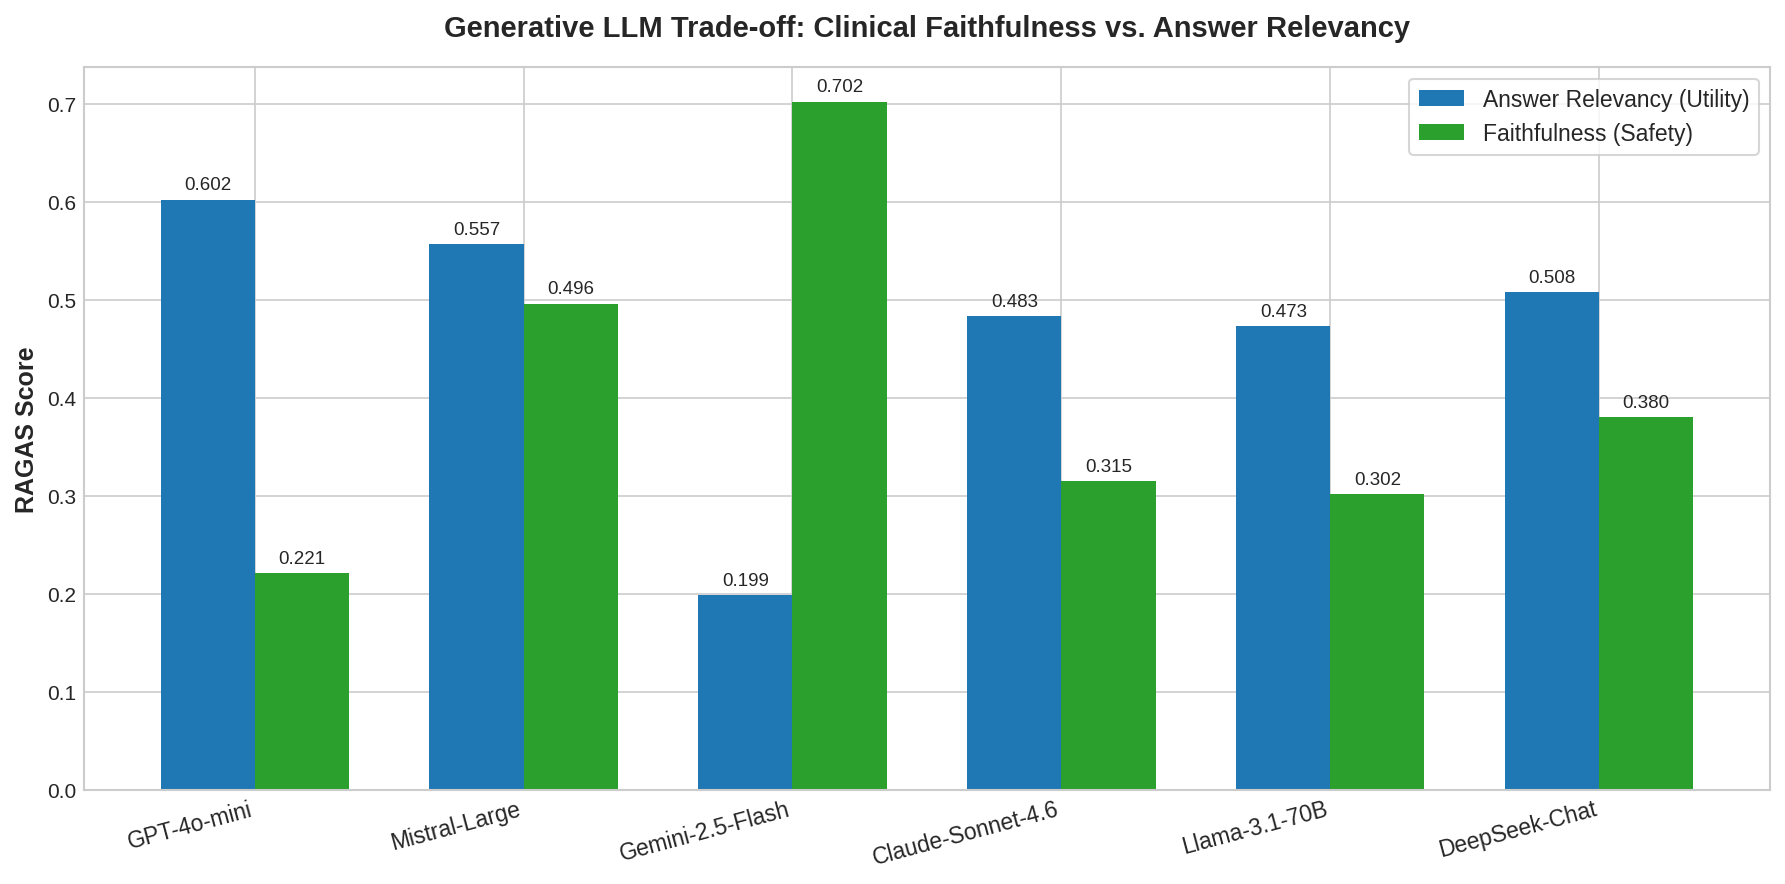

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. The Data from your Evaluation
models = ['GPT-4o-mini', 'Mistral-Large', 'Gemini-2.5-Flash', 'Claude-Sonnet-4.6', 'Llama-3.1-70B', 'DeepSeek-Chat']
relevancy = [0.602, 0.557, 0.199, 0.483, 0.473, 0.508]
faithfulness = [0.221, 0.496, 0.702, 0.315, 0.302, 0.380]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

# 2. Set up the plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

# 3. Create the bars
rects1 = ax.bar(x - width/2, relevancy, width, label='Answer Relevancy (Utility)', color='#1f77b4')
rects2 = ax.bar(x + width/2, faithfulness, width, label='Faithfulness (Safety)', color='#2ca02c')

# 4. Add labels, title, and formatting
ax.set_ylabel('RAGAS Score', fontsize=12, fontweight='bold')
ax.set_title('Generative LLM Trade-off: Clinical Faithfulness vs. Answer Relevancy', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=11)
ax.legend(loc='upper right', fontsize=11, frameon=True)

# 5. Add value labels on top of the bars
ax.bar_label(rects1, padding=3, fmt='%.3f', fontsize=9)
ax.bar_label(rects2, padding=3, fmt='%.3f', fontsize=9)

plt.tight_layout()

# 6. Save the image so you can use it in LaTeX!
plt.savefig('/content/drive/MyDrive/llm_battle_chart.png', bbox_inches='tight')
plt.show()

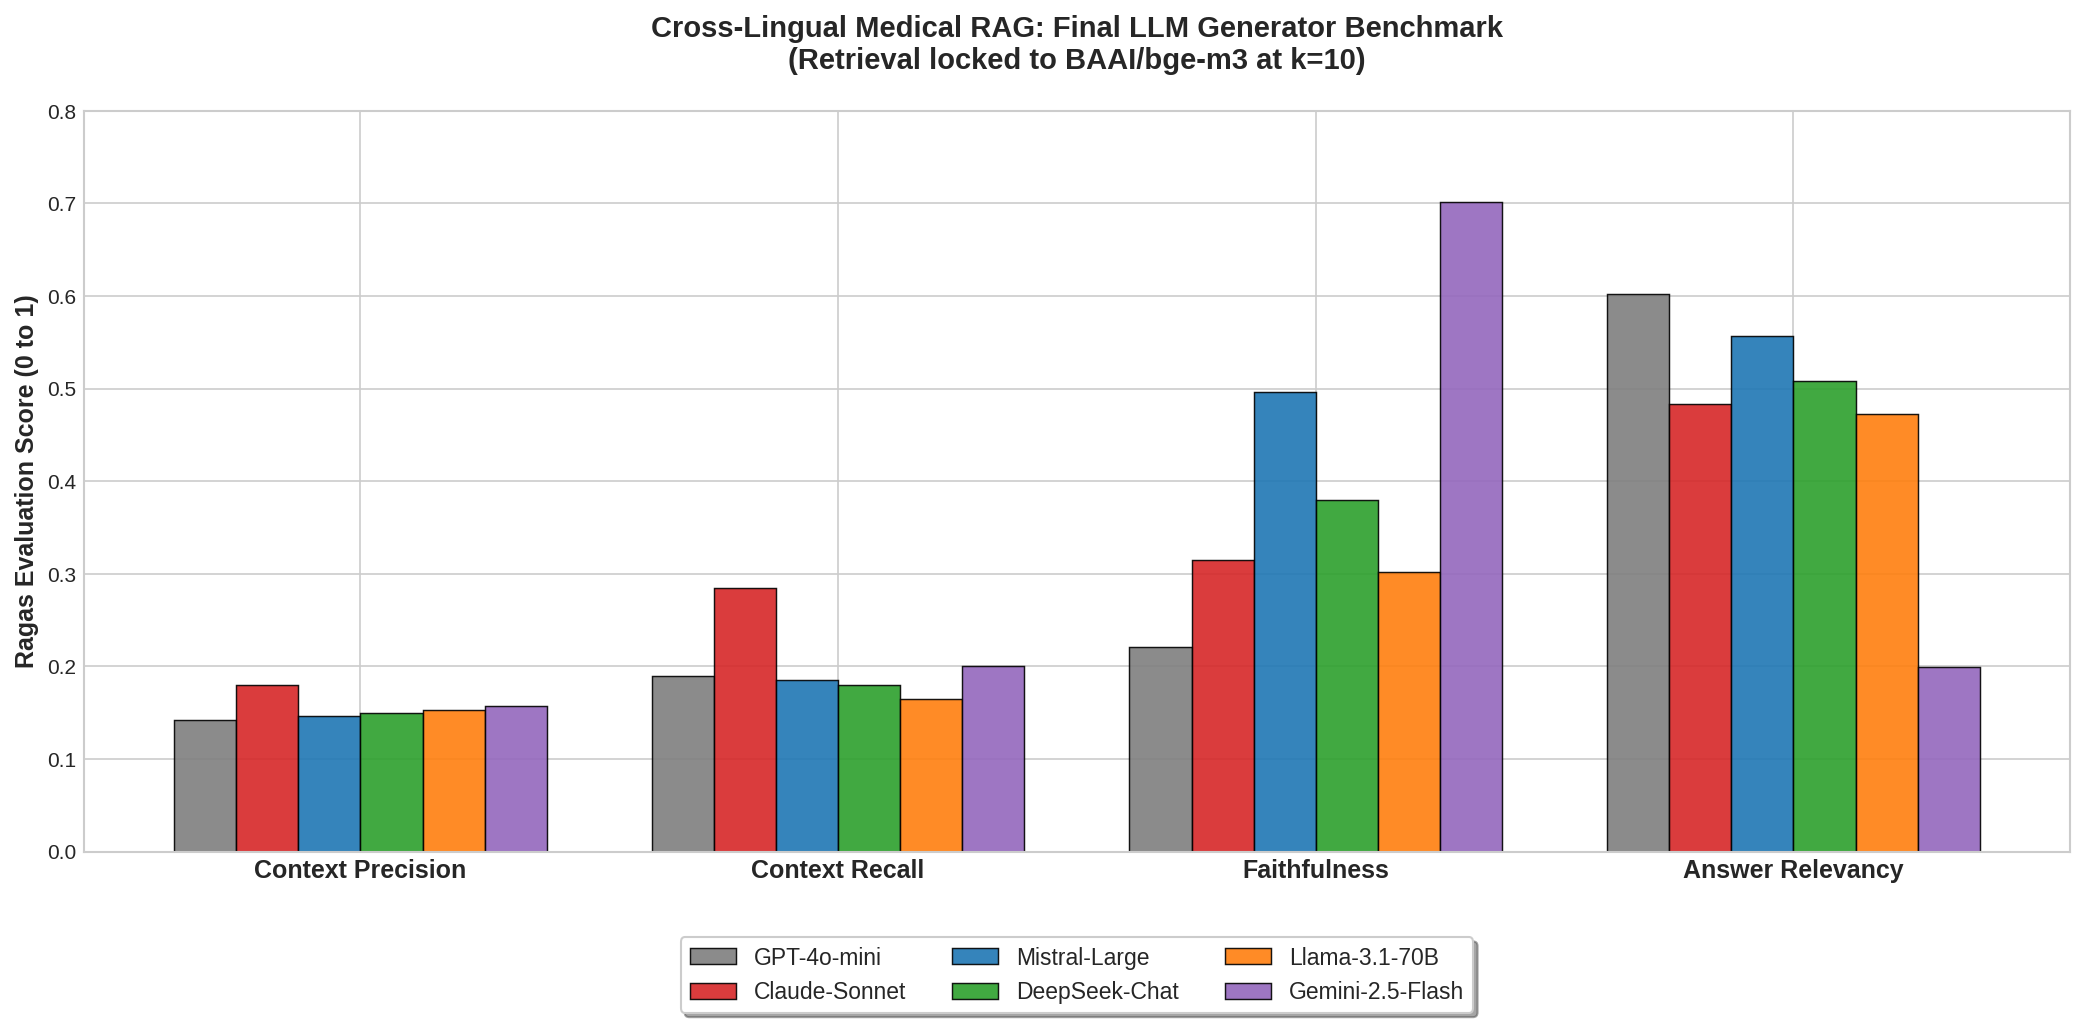

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. The Data
models = ['GPT-4o-mini', 'Claude-Sonnet', 'Mistral-Large', 'DeepSeek-Chat', 'Llama-3.1-70B', 'Gemini-2.5-Flash']
metrics = ['Context Precision', 'Context Recall', 'Faithfulness', 'Answer Relevancy']

# Scores matrix: [Precision, Recall, Faithfulness, Relevancy] for each model
scores = {
    'GPT-4o-mini': [0.142, 0.190, 0.221, 0.602],
    'Claude-Sonnet': [0.180, 0.285, 0.315, 0.483],
    'Mistral-Large': [0.147, 0.185, 0.496, 0.557],
    'DeepSeek-Chat': [0.150, 0.180, 0.380, 0.508],
    'Llama-3.1-70B': [0.153, 0.165, 0.302, 0.473],
    'Gemini-2.5-Flash': [0.157, 0.200, 0.702, 0.199]
}

# 2. Plot Setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

x = np.arange(len(metrics))  # the label locations
width = 0.13  # the width of the bars
multiplier = 0

# Professional Academic Color Palette
colors = ['#7f7f7f', '#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']

# 3. Draw the Bars
for (model, color) in zip(models, colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, scores[model], width, label=model, color=color, edgecolor='black', linewidth=0.7, alpha=0.9)
    multiplier += 1

# 4. Formatting and Labels
ax.set_ylabel('Ragas Evaluation Score (0 to 1)', fontsize=12, fontweight='bold')
ax.set_title('Cross-Lingual Medical RAG: Final LLM Generator Benchmark\n(Retrieval locked to BAAI/bge-m3 at k=10)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.8) # Set ceiling to 0.8 to fit the highest Gemini score comfortably

# Add Legend outside the plot area
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=11, frameon=True, shadow=True)

plt.tight_layout()

# 5. Save to Drive
plt.savefig('/content/drive/MyDrive/FINAL_LLM_BATTLE_Barchart.png', bbox_inches='tight')
plt.show()

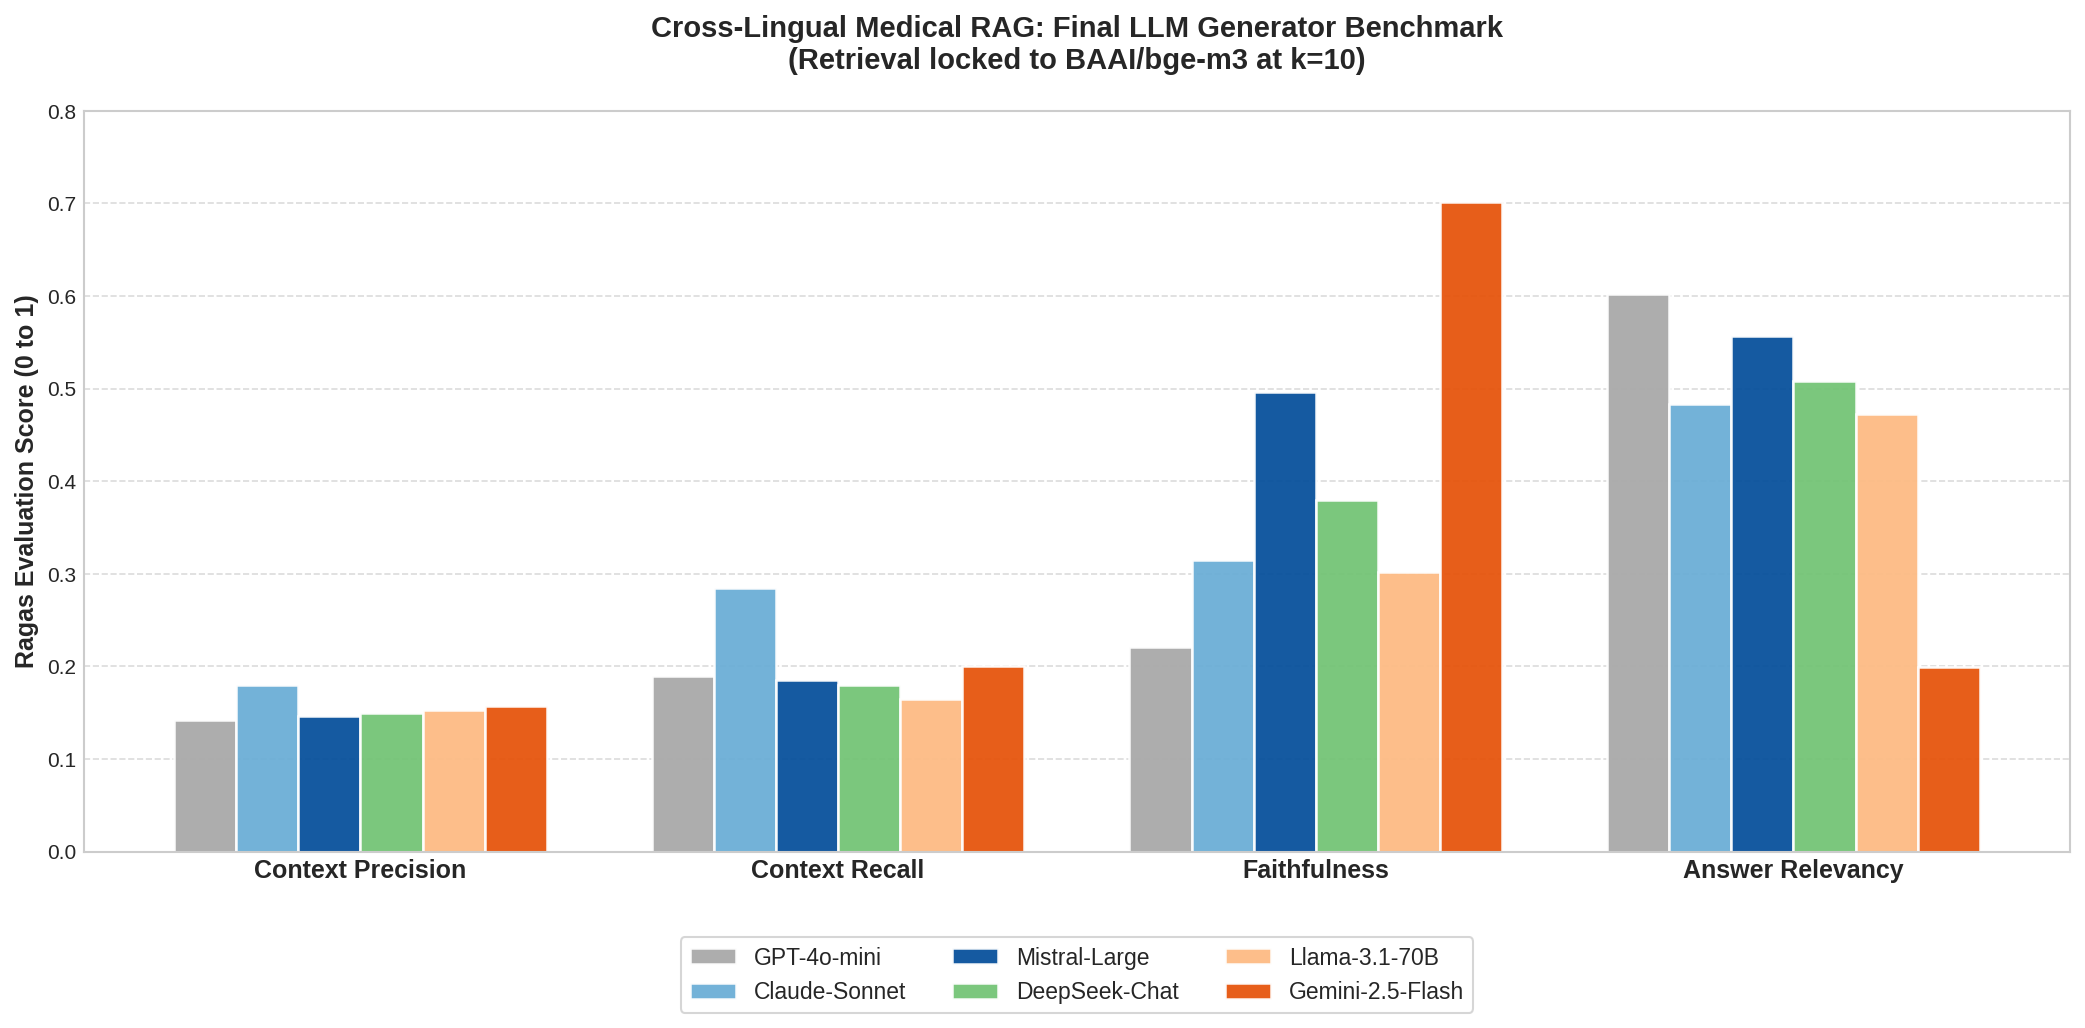

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. The Data
models = ['GPT-4o-mini', 'Claude-Sonnet', 'Mistral-Large', 'DeepSeek-Chat', 'Llama-3.1-70B', 'Gemini-2.5-Flash']
metrics = ['Context Precision', 'Context Recall', 'Faithfulness', 'Answer Relevancy']

# Scores matrix: [Precision, Recall, Faithfulness, Relevancy] for each model
scores = {
    'GPT-4o-mini': [0.142, 0.190, 0.221, 0.602],
    'Claude-Sonnet': [0.180, 0.285, 0.315, 0.483],
    'Mistral-Large': [0.147, 0.185, 0.496, 0.557],
    'DeepSeek-Chat': [0.150, 0.180, 0.380, 0.508],
    'Llama-3.1-70B': [0.153, 0.165, 0.302, 0.473],
    'Gemini-2.5-Flash': [0.157, 0.200, 0.702, 0.199]
}

# 2. Plot Setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

x = np.arange(len(metrics))  # the label locations
width = 0.13  # the width of the bars
multiplier = 0

# 3. Professional Academic Color Palette (Tells a visual story)
colors = [
    '#A9A9A9', # Neutral Grey: GPT-4o-mini (Baseline)
    '#6BAED6', # Soft Blue: Claude-Sonnet
    '#08519C', # Deep Bold Blue: Mistral-Large (The Selected Winner)
    '#74C476', # Muted Green: DeepSeek-Chat
    '#FDBB84', # Soft Peach: Llama-3.1-70B
    '#E6550D'  # Deep Rust/Red: Gemini-2.5-Flash (The outlier)
]

# 4. Draw the Bars (Added white edgecolors for a cleaner, modern separation)
for (model, color) in zip(models, colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, scores[model], width, label=model, color=color, edgecolor='white', linewidth=1.2, alpha=0.95)
    multiplier += 1

# 5. Formatting and Labels
ax.set_ylabel('Ragas Evaluation Score (0 to 1)', fontsize=12, fontweight='bold')
ax.set_title('Cross-Lingual Medical RAG: Final LLM Generator Benchmark\n(Retrieval locked to BAAI/bge-m3 at k=10)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width * 2.5)
ax.set_xticklabels(metrics, fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.8) # Set ceiling to 0.8 to fit the highest Gemini score comfortably

# Add Legend outside the plot area
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=11, frameon=True, shadow=False)

# Add a subtle grid behind the bars for easier reading
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

plt.tight_layout()

# 6. Save to Drive
plt.savefig('/content/drive/MyDrive/FINAL_LLM_BATTLE_Barchart.png', bbox_inches='tight')
plt.show()